<a href="https://colab.research.google.com/github/bchirabenyoussef-hash/Machine_learning/blob/main/Machine_learning_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: rows= 100000 cols= 10

--- Head ---
   HasDetections  Wdft_IsGamer  Census_IsVirtualDevice Census_OSEdition  \
0              0           0.0                     0.0     Professional   
1              0           0.0                     0.0     Professional   
2              0           0.0                     0.0             Core   
3              1           0.0                     0.0     Professional   
4              1           0.0                     0.0             Core   

   Census_HasOpticalDiskDrive  Firewall  SMode  IsProtected  \
0                           0       1.0    0.0          1.0   
1                           0       1.0    0.0          1.0   
2                           0       1.0    0.0          1.0   
3                           0       1.0    0.0          1.0   
4                           0       1.0    0.0          1.0   

  OsPlatformSubRelease  CountryIdentifier  
0                  rs4                 29  
1                  rs4        

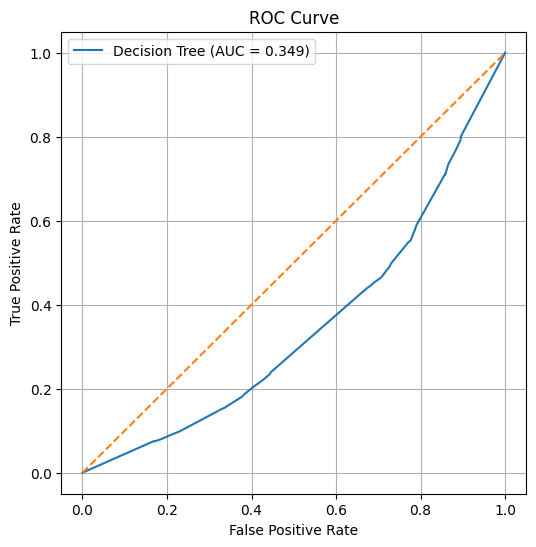

ROC AUC: 0.3486878428594579


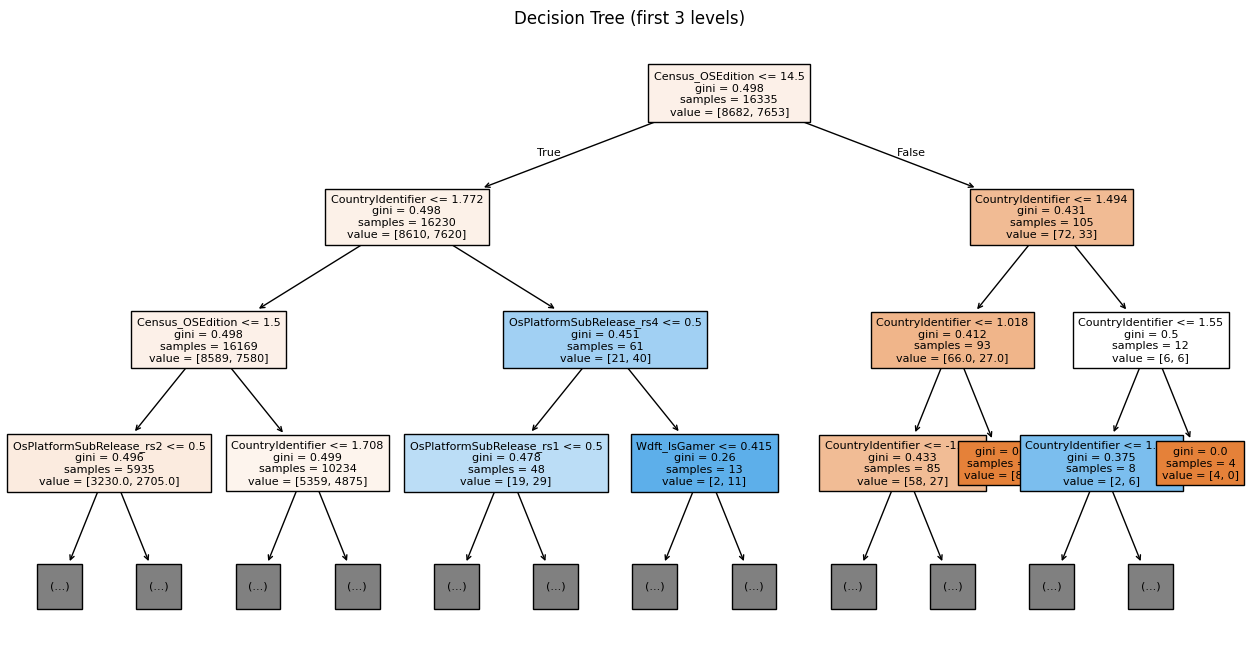

Starting GridSearchCV (this may take time)...
Best params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best score: 0.5087474949543623

Classification report (best model):
              precision    recall  f1-score   support

           0       0.53      0.98      0.69      2171
           1       0.50      0.02      0.04      1913

    accuracy                           0.53      4084
   macro avg       0.52      0.50      0.36      4084
weighted avg       0.52      0.53      0.39      4084

Test ROC AUC (best): 0.5144221589391885

PCA explained variance ratio (2 comps): [0.13597784 0.12648642]


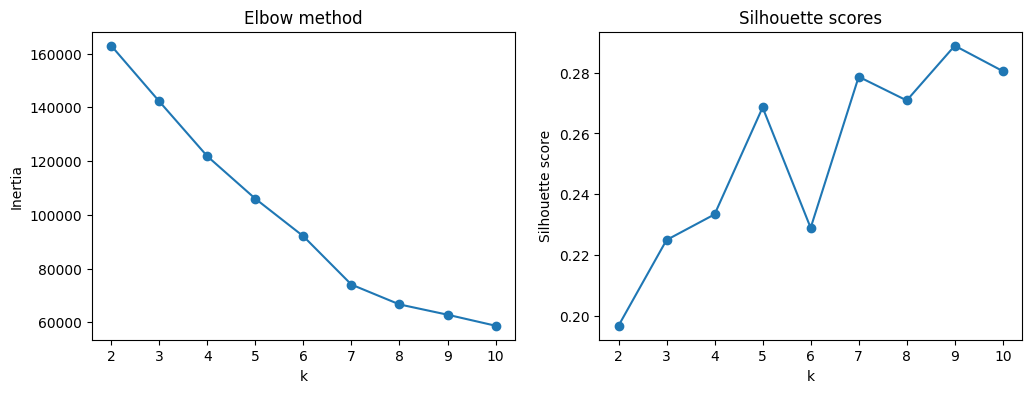

Suggested best_k by silhouette: 9


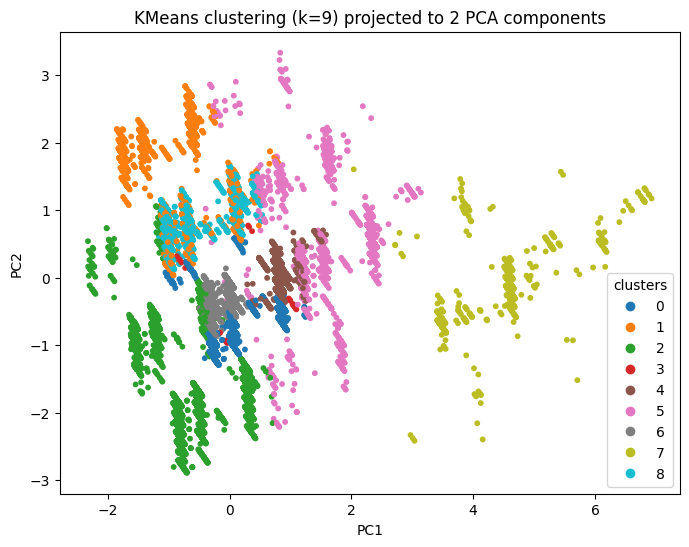


Cluster summary (aggregates):
cluster                                     0            1            2  \
Wdft_IsGamer               mean      0.009086     0.381205     0.249636   
                           count  1761.000000  3022.000000  3433.000000   
Census_IsVirtualDevice     mean      0.000000     0.000000     0.000000   
                           count  1761.000000  3022.000000  3433.000000   
Census_OSEdition           mean      5.281090     5.841165     5.259248   
                           count  1761.000000  3022.000000  3433.000000   
Census_HasOpticalDiskDrive mean      0.050539     1.000000     0.123216   
                           count  1761.000000  3022.000000  3433.000000   
Firewall                   mean      1.000000     1.000000     1.000000   
                           count  1761.000000  3022.000000  3433.000000   
SMode                      mean      0.000000     0.000000     0.000000   
                           count  1761.000000  3022.000000  3433.0000

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: profile report
try:
    from ydata_profiling import ProfileReport
except Exception:
    ProfileReport = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# Cell 2: Load dataset
# -------------------------
DATA_PATH = '/content/Microsoft_malware_dataset_min.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}. Please place the CSV in the working directory or update DATA_PATH.")

df = pd.read_csv(DATA_PATH)
print('Dataset loaded: rows=', df.shape[0], 'cols=', df.shape[1])

# -------------------------
# Cell 3: Basic exploration
# -------------------------
print('\n--- Head ---')
print(df.head())

print('\n--- Info ---')
print(df.info())

print('\n--- Describe (numeric) ---')
print(df.describe().T)

print('\n--- Missing values (%) per column ---')
missing_pct = df.isna().mean().sort_values(ascending=False)
print(missing_pct[missing_pct>0].round(4))

# -------------------------
# Cell 4: Pandas Profiling (optional)
# -------------------------
if ProfileReport is not None:
    print('\nGenerating profile report (this may take a few minutes)...')
    profile = ProfileReport(df, title='Microsoft Malware Dataset Profiling', explorative=True)
    profile.to_file('microsoft_malware_profile.html')
    print('Profile saved to microsoft_malware_profile.html')
else:
    print('\nProfileReport (ydata_profiling) not installed. To enable, run: pip install ydata-profiling')

# -------------------------
# Cell 5: Handle duplicates
# -------------------------
dup_count = df.duplicated().sum()
print(f'Found {dup_count} duplicated rows')
if dup_count>0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)

# -------------------------
# Cell 6: Target identification
# -------------------------
# Common Microsoft malware competition target: 'HasDetections' (binary 0/1). Update if your target differs.
possible_targets = ['HasDetections', 'HasDetection', 'Infected', 'Class']
existing_targets = [c for c in df.columns if c in possible_targets]
if len(existing_targets)==0:
    # Fallback: assume the last column is the target (common in some simplified datasets)
    target = df.columns[-1]
    print('No standard target column found. Using last column as target:', target)
else:
    target = existing_targets[0]
    print('Detected target column:', target)

# Show target distribution
print('\nTarget distribution:')
print(df[target].value_counts(dropna=False))

# -------------------------
# Cell 7: Missing values strategy & splitting features
# -------------------------
# Separate features and target early for consistent preprocessing
X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print('\nNumeric cols:', len(numeric_cols))
print('Categorical cols:', len(cat_cols))

# We'll impute numeric with median and categorical with constant 'missing' or most frequent depending on cardinality
numeric_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')

# For encoding: use OneHot for low-cardinality, Ordinal for high-card.
LOW_CARDINALITY = 10
low_card_cols = [c for c in cat_cols if X[c].nunique() <= LOW_CARDINALITY]
high_card_cols = [c for c in cat_cols if X[c].nunique() > LOW_CARDINALITY]
print('\nLow-cardinality categorical:', len(low_card_cols))
print('High-cardinality categorical:', len(high_card_cols))

# -------------------------
# Cell 8: Outlier detection and handling (IQR-based for numeric features)
# -------------------------
# Mark extreme outliers as NaN so they get imputed, or optionally clip them.
X_num = X[numeric_cols].copy()
Q1 = X_num.quantile(0.25)
Q3 = X_num.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a mask of outliers
outlier_mask = (X_num < lower_bound) | (X_num > upper_bound)
outlier_counts = outlier_mask.sum().sum()
print(f'Found approx {outlier_counts} cell-level outliers across numeric columns (IQR method)')

# Option 1: Clip numeric values to [lower_bound, upper_bound]
X[numeric_cols] = X[numeric_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)
print('Applied clipping to numeric columns to handle outliers.')

# -------------------------
# Cell 9: Preprocessing pipelines
# -------------------------
# Numeric pipeline: impute median -> scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Low-card categorical: impute missing -> OneHot
low_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# High-card categorical: impute missing -> OrdinalEncoder (risk of order but saves dimensionality)
high_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('lowcat', low_card_transformer, low_card_cols),
    ('highcat', high_card_transformer, high_card_cols),
], remainder='drop')

# -------------------------
# Cell 10: Prepare model pipeline (Decision Tree)
# -------------------------
# Encode target if needed
le = None
if y.dtype == 'object' or y.dtype.name == 'category':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y.astype(str))
else:
    y_encoded = y.values

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)
print('\nShapes -> X_train:', X_train.shape, 'X_test:', X_test.shape)

# Fit baseline model
clf.fit(X_train, y_train)
print('\nBaseline Decision Tree trained.')

# -------------------------
# Cell 11: Baseline evaluation + ROC curve
# -------------------------
# Prediction and basic metrics
y_pred = clf.predict(X_test)
print('\nClassification report:')
print(classification_report(y_test, y_pred))

# ROC curve: handle binary and multiclass
y_prob = None
if hasattr(clf.named_steps['classifier'], 'predict_proba'):
    y_prob = clf.predict_proba(X_test)

# If binary
if y_prob is not None and y_prob.shape[1] == 2:
    fpr, tpr, _ = roc_curve(y_test, y_prob[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    print('ROC AUC:', roc_auc)
else:
    # Multiclass: use one-vs-rest ROC AUC if necessary
    print('Multiclass or no predict_proba available. Computing macro ROC AUC where possible...')
    try:
        from sklearn.preprocessing import label_binarize
        n_classes = len(np.unique(y_test))

        if y_prob is not None and n_classes > 2:
            y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
            # y_prob shape: [n_samples, n_classes]
            # compute ROC AUC per class and macro
            aucs = []
            plt.figure(figsize=(7, 6))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)
                aucs.append(roc_auc)
                plt.plot(fpr, tpr, label=f'class {i} (AUC={roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], '--')
            plt.legend()
            plt.title('One-vs-rest ROC curves')
            plt.show()
            print('Macro AUC:', np.mean(aucs))
        else:
            print('Cannot compute ROC AUC for given model/output.')
    except ImportError:
        print('Could not import label_binarize. Please ensure scikit-learn is installed correctly.')
    except Exception as e:
        print(f'An error occurred during multiclass ROC AUC calculation: {e}')

# -------------------------
# Cell 12: Visualize Decision Tree (small depth recommended)
# -------------------------
plt.figure(figsize=(16,8))
# Extract trained decision tree from pipeline
dt = clf.named_steps['classifier']
# We need to access the feature names created by ColumnTransformer
# Create feature names helper
def get_feature_names_from_column_transformer(ct):
    feature_names = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'named_steps') and 'onehot' in trans.named_steps:
            ohe = trans.named_steps['onehot']
            # handle categories_
            cols_ohe = list(ohe.get_feature_names_out(cols))
            feature_names.extend(cols_ohe)
        else:
            feature_names.extend(cols)
    return feature_names

try:
    feature_names = get_feature_names_from_column_transformer(preprocessor)
    plot_tree(dt, feature_names=feature_names, max_depth=3, filled=True, fontsize=8)
    plt.title('Decision Tree (first 3 levels)')
    plt.show()
except Exception as e:
    print('Could not plot full tree due to feature-name issues:', e)
    # fallback: plot without feature names
    plot_tree(dt, max_depth=3, filled=True)
    plt.show()

# -------------------------
# Cell 13: Hyperparameter tuning (GridSearchCV)
# -------------------------
param_grid = {
    'classifier__max_depth': [3, 5, 8, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
}

grid = GridSearchCV(clf, param_grid, scoring='roc_auc' if (len(np.unique(y_encoded))==2) else 'accuracy', cv=5, n_jobs=-1)
print('Starting GridSearchCV (this may take time)...')
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best score:', grid.best_score_)

best_model = grid.best_estimator_

# Evaluate on test
y_pred_best = best_model.predict(X_test)
print('\nClassification report (best model):')
print(classification_report(y_test, y_pred_best))

if hasattr(best_model.named_steps['classifier'], 'predict_proba'):
    y_prob_best = best_model.predict_proba(X_test)
    if y_prob_best.shape[1]==2:
        fpr, tpr, _ = roc_curve(y_test, y_prob_best[:,1])
        print('Test ROC AUC (best):', auc(fpr, tpr))

# -------------------------
# Part 2: Unsupervised learning - KMeans clustering
# -------------------------
# Cell 14: Prepare data for clustering (drop target, minimal preprocessing)
X_clust = df.drop(columns=[target]).copy()

# Simple preprocessing: impute numeric median, categorical -> ordinal (to get numeric) and scale
for col in X_clust.select_dtypes(include=['object', 'category']).columns:
    X_clust[col] = X_clust[col].fillna('missing').astype(str)

for col in X_clust.select_dtypes(include=['int64','float64']).columns:
    X_clust[col] = X_clust[col].fillna(X_clust[col].median())

# Convert categorical to ordinal (Label encoding per column) to reduce dimensionality for kmeans
for col in X_clust.select_dtypes(include=['object']).columns:
    X_clust[col] = X_clust[col].astype('category').cat.codes

scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# Optionally reduce dimensionality for plotting
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust_scaled)
print('\nPCA explained variance ratio (2 comps):', pca.explained_variance_ratio_)

# Cell 15: Find optimal K (Elbow + Silhouette)
ks = list(range(2,11))
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(ks, silhouettes, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores')
plt.show()

# Choose best k (example: highest silhouette)
best_k = ks[int(np.argmax(silhouettes))]
print('Suggested best_k by silhouette:', best_k)

# Cell 16: Run KMeans with chosen k and plot clusters
k_final = best_k
km_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=20)
labels_final = km_final.fit_predict(X_clust_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_final, cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title='clusters')
plt.title(f'KMeans clustering (k={k_final}) projected to 2 PCA components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Cell 17: Interpret clusters
cluster_summary = pd.DataFrame(X_clust).assign(cluster=labels_final).groupby('cluster').agg(['mean', 'count']).T
print('\nCluster summary (aggregates):')
print(cluster_summary.head(40))

# Optional: compare cluster assignment with target
print('\nTarget distribution per cluster:')
cluster_target = pd.DataFrame({ 'cluster': labels_final, 'target': df[target].values })
print(cluster_target.groupby('cluster')['target'].value_counts(normalize=True).unstack(fill_value=0))

# -------------------------
# Cell 18: Short notes & interpretation
# -------------------------
notes = '''
Notes / Next steps:
- If many categorical variables have high cardinality, consider target encoding or frequency encoding instead of ordinal.
- For Decision Tree, performance may be limited if features are noisy; consider RandomForest or XGBoost for improvement.
- For imbalance in the target (typical in malware datasets), consider stratified sampling (done above) and metrics such as precision-recall AUC.
- For clustering, PCA projection helps visualization but clusters in PCA space might not reflect separability in original space.
- Save trained models (joblib.dump) if you want reproducibility.
'''
print(notes)

# End of script
print('Script finished. Review outputs and the saved profile HTML (if generated).')
